# Fusion + Forecast Accuracy

Sanity-checks the forecasting and fusion pipeline. Two parts:

**Forecast accuracy** — how well do ARIMA / LSTM / Best_Model predict
actual closes on the 60-day walk-forward backtest? Measured with
MAPE, RMSE, and directional hit-rate.

**Fusion sanity** — does the adaptive fusion engine produce sensible
Health labels? Checks: best-model selection, fusion-vs-forecast-only
agreement, divergence-damping audit, internal consistency.

Strict end-to-end *fusion* backtesting needs historical news sentiment
and historical technicals at past dates — we only have today's snapshot,
so we measure what we can. Run from project root after
`python -m ml_services.forecasting` and `python -m ml_services.stock_health`.

In [1]:
import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'manage.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'integrations' / 'data'

forecasts = pd.DataFrame(json.loads((DATA / 'stock_forecasts.json').read_text()))
summaries = pd.DataFrame(json.loads((DATA / 'best_models.json').read_text()))
stocks    = json.loads((DATA / 'stocks.json').read_text())
historical = pd.DataFrame(json.loads((DATA / 'historical_data.json').read_text()))

forecasts['Date']  = pd.to_datetime(forecasts['Date'])
historical['Date'] = pd.to_datetime(historical['Date'])

print(f'forecasts: {len(forecasts)} rows / {forecasts.Symbol.nunique()} symbols')
print(f'summaries: {len(summaries)}')
print(f'stocks:    {len(stocks)}')

forecasts: 1140 rows / 19 symbols
summaries: 19
stocks:    19


## 1. Forecast accuracy — MAPE & RMSE

In [2]:
def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = ~np.isnan(pred) & (actual != 0)
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs(actual[mask] - pred[mask]) / np.abs(actual[mask])) * 100)

def rmse(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = ~np.isnan(pred)
    if not mask.any():
        return np.nan
    return float(np.sqrt(np.mean((actual[mask] - pred[mask]) ** 2)))

rows = []
for sym, g in forecasts.groupby('Symbol'):
    rows.append({
        'Symbol': sym,
        'ARIMA_MAPE_%': round(mape(g.Close, g.Forecasting_ARIMA), 2),
        'LSTM_MAPE_%':  round(mape(g.Close, g.Forecasting_LSTM),  2),
        'Best_MAPE_%':  round(mape(g.Close, g.Forecasting_Best),  2),
        'ARIMA_RMSE':   round(rmse(g.Close, g.Forecasting_ARIMA), 4),
        'LSTM_RMSE':    round(rmse(g.Close, g.Forecasting_LSTM),  4),
        'Best_RMSE':    round(rmse(g.Close, g.Forecasting_Best),  4),
        'Best_Model':   g.Best_Model.iloc[0],
    })
metrics = pd.DataFrame(rows).sort_values('Best_MAPE_%')
print(f"avg ARIMA MAPE: {metrics['ARIMA_MAPE_%'].mean():.2f}%")
print(f"avg LSTM  MAPE: {metrics['LSTM_MAPE_%'].mean():.2f}%")
print(f"avg Best  MAPE: {metrics['Best_MAPE_%'].mean():.2f}%")
metrics

avg ARIMA MAPE: 4.20%
avg LSTM  MAPE: 13.03%
avg Best  MAPE: 3.25%


,Symbol,ARIMA_MAPE_%,LSTM_MAPE_%,Best_MAPE_%,ARIMA_RMSE,LSTM_RMSE,Best_RMSE,Best_Model
11,NESTLE,1.40,1.01,1.01,141.7695,109.2385,109.2385,LSTM
13,POL,2.03,1.13,1.13,17.2467,10.8049,10.8049,LSTM
8,MCB,2.92,1.98,1.98,15.3060,10.7824,10.7824,LSTM
7,MARI,3.86,2.29,2.29,34.4446,19.5511,19.5511,LSTM
15,PSO,4.74,2.59,2.59,24.0096,13.1576,13.1576,LSTM
14,PPL,5.42,2.83,2.83,14.7309,7.9047,7.9047,LSTM
4,HBL,4.02,2.93,2.93,15.4141,11.5376,11.5376,LSTM
3,FFC,3.13,52.89,3.13,21.3448,283.0495,21.3448,ARIMA
6,LUCK,4.43,3.29,3.29,22.6645,17.0016,17.0016,LSTM
2,ENGRO,3.81,3.48,3.48,23.2248,21.7030,21.7030,LSTM


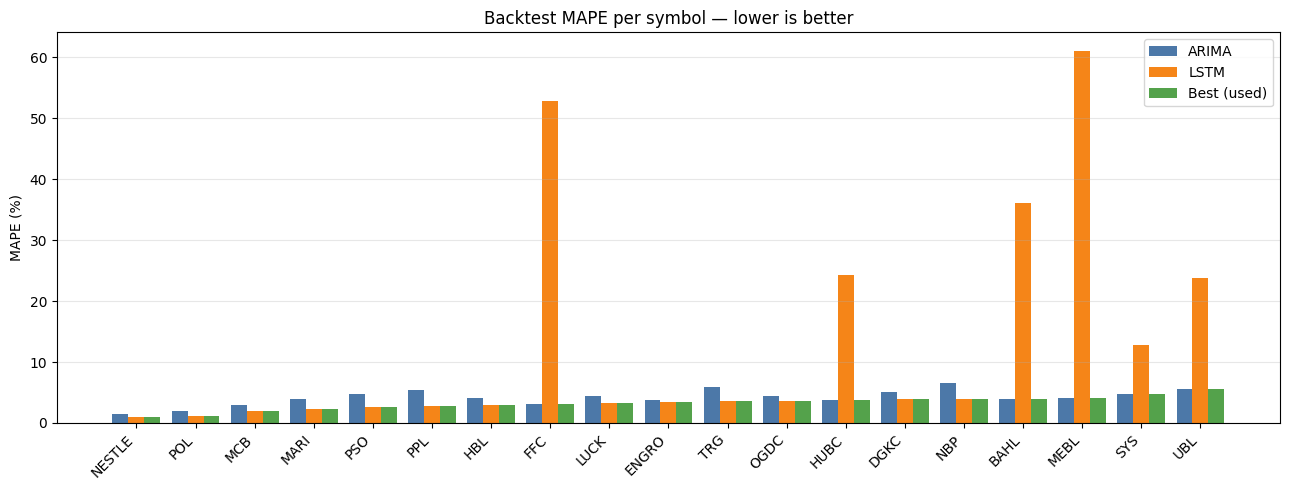

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics))
w = 0.27
ax.bar(x - w, metrics['ARIMA_MAPE_%'], width=w, label='ARIMA',     color='#4c78a8')
ax.bar(x,     metrics['LSTM_MAPE_%'],  width=w, label='LSTM',      color='#f58518')
ax.bar(x + w, metrics['Best_MAPE_%'],  width=w, label='Best (used)', color='#54a24b')
ax.set_xticks(x)
ax.set_xticklabels(metrics.Symbol, rotation=45, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('Backtest MAPE per symbol — lower is better')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

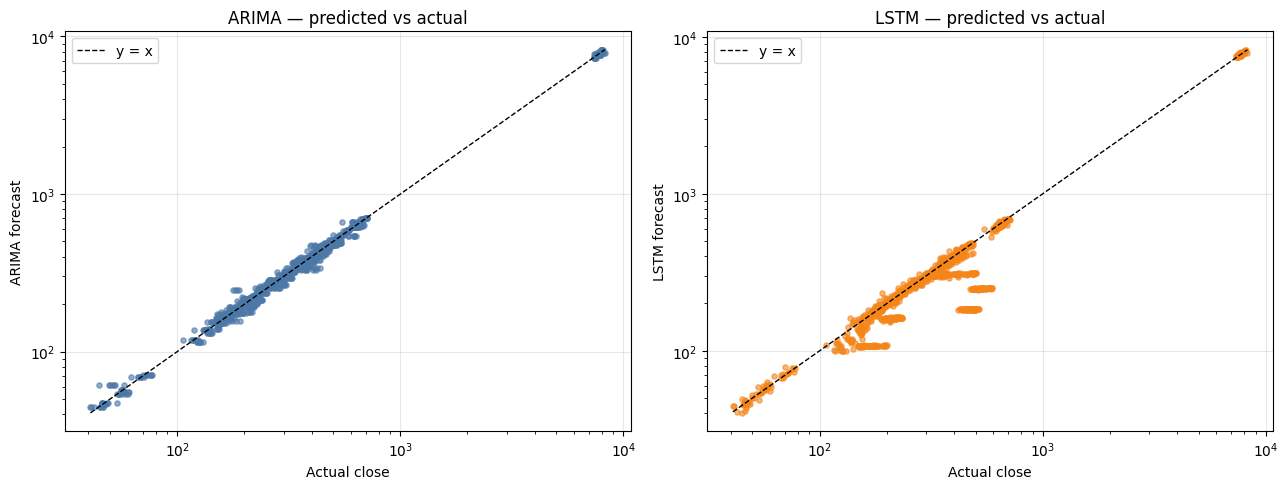

In [4]:
# Predicted vs actual scatter — points should hug the y=x line.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, color, title in [
    (axes[0], 'Forecasting_ARIMA', '#4c78a8', 'ARIMA'),
    (axes[1], 'Forecasting_LSTM',  '#f58518', 'LSTM'),
]:
    valid = forecasts[forecasts[col].notna()]
    ax.scatter(valid.Close, valid[col], s=14, alpha=0.6, color=color)
    lo, hi = valid.Close.min(), valid.Close.max()
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x')
    ax.set_xlabel('Actual close')
    ax.set_ylabel(f'{title} forecast')
    ax.set_title(f'{title} — predicted vs actual')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 2. Forecast direction hit-rate

Hit = the model's `Direction_*` matches the actual day-over-day move.
Threshold for `STABLE` is ±0.5%. The first day of each symbol's backtest
is compared against the close on the day immediately before the test
window (pulled from `historical_data.json`).

In [5]:
# Use the SAME per-stock dynamic threshold for the actual direction
# label as the forecasting module used for the prediction. This is
# the apples-to-apples comparison the previous run lacked.
thresholds = forecasts.groupby('Symbol').DirectionThreshold.first().to_dict()

def direction(prev, curr, threshold=0.005):
    if prev == 0 or any(map(math.isnan, (prev, curr))):
        return 'STABLE'
    diff = (curr - prev) / abs(prev)
    if diff > threshold:  return 'UP'
    if diff < -threshold: return 'DOWN'
    return 'STABLE'

first_dates = forecasts.groupby('Symbol').Date.min().to_dict()
prior_close = {}
for sym, d in first_dates.items():
    prior = historical[(historical.Symbol == sym) & (historical.Date < d)]
    if not prior.empty:
        prior_close[sym] = float(prior.sort_values('Date').Close.iloc[-1])

rows = []
for sym, g in forecasts.sort_values('Date').groupby('Symbol'):
    prev = prior_close.get(sym)
    if prev is None:
        continue
    t = thresholds.get(sym, 0.005)
    hits = {'ARIMA': 0, 'LSTM': 0, 'Best': 0}
    n = 0
    for _, r in g.iterrows():
        actual = direction(prev, r.Close, t)
        for tag, key in [('ARIMA', 'Direction_ARIMA'), ('LSTM', 'Direction_LSTM'), ('Best', 'Direction_Best')]:
            if r[key] == actual:
                hits[tag] += 1
        prev = r.Close
        n += 1
    rows.append({'Symbol': sym, **{f'{k}_hit_%': round(v/n*100, 1) for k, v in hits.items()},
                 'Days': n, 'Threshold_%': round(t * 100, 3)})
dir_df = pd.DataFrame(rows).sort_values('Best_hit_%', ascending=False)
print('overall direction hit rates with per-stock dynamic thresholds:')
print(f'  ARIMA: {dir_df["ARIMA_hit_%"].mean():.1f}%')
print(f'  LSTM : {dir_df["LSTM_hit_%"].mean():.1f}%')
print(f'  Best : {dir_df["Best_hit_%"].mean():.1f}%')
print(f'\nthreshold range: {dir_df["Threshold_%"].min():.2f}% – {dir_df["Threshold_%"].max():.2f}%')
dir_df

overall direction hit rates with per-stock dynamic thresholds:
  ARIMA: 38.5%
  LSTM : 37.4%
  Best : 35.4%

threshold range: 0.50% – 0.66%


,Symbol,ARIMA_hit_%,LSTM_hit_%,Best_hit_%,Days,Threshold_%
12,OGDC,36.7,45.0,45.0,60,0.535
8,MCB,33.3,43.3,43.3,60,0.500
4,HBL,41.7,43.3,43.3,60,0.500
9,MEBL,41.7,46.7,41.7,60,0.500
16,SYS,40.0,40.0,40.0,60,0.500
3,FFC,40.0,40.0,40.0,60,0.500
5,HUBC,38.3,41.7,38.3,60,0.500
11,NESTLE,43.3,38.3,38.3,60,0.500
0,BAHL,36.7,46.7,36.7,60,0.500
7,MARI,35.0,35.0,35.0,60,0.500


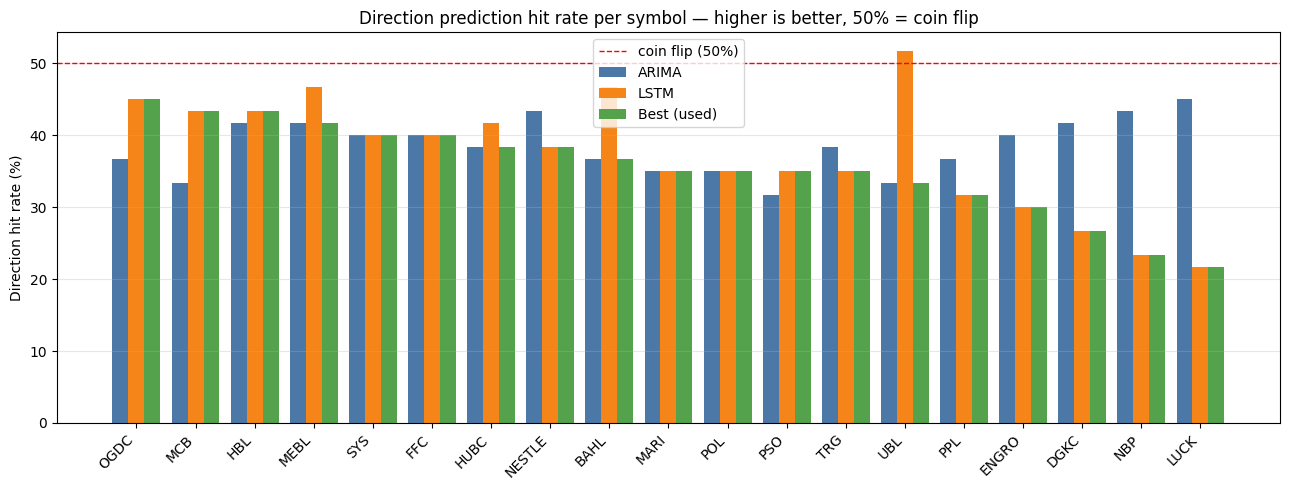

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(dir_df))
w = 0.27
ax.bar(x - w, dir_df['ARIMA_hit_%'], width=w, label='ARIMA',         color='#4c78a8')
ax.bar(x,     dir_df['LSTM_hit_%'],  width=w, label='LSTM',          color='#f58518')
ax.bar(x + w, dir_df['Best_hit_%'],  width=w, label='Best (used)',   color='#54a24b')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='coin flip (50%)')
ax.set_xticks(x)
ax.set_xticklabels(dir_df.Symbol, rotation=45, ha='right')
ax.set_ylabel('Direction hit rate (%)')
ax.set_title('Direction prediction hit rate per symbol — higher is better, 50% = coin flip')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Fusion sanity checks

In [7]:
# Was the chosen Best_Model actually the lower-MAPE one?
correct = total = 0
for s in summaries.itertuples(index=False):
    a, l = s.ARIMA_MAPE, s.LSTM_MAPE
    if pd.isna(a) or pd.isna(l):
        continue
    expected = 'ARIMA' if a <= l else 'LSTM'
    total += 1
    if s.Best_Model == expected:
        correct += 1
print(f'Best_Model selection: {correct}/{total} correct ({correct/total*100:.1f}%)')

Best_Model selection: 19/19 correct (100.0%)


In [8]:
# Disagreement between forecast-only and the fused Health label is
# *expected* in cases where damping fired or sentiment/technicals
# overruled the forecast. We surface flips for review, not as errors.
DIRECTION_HEALTH = {
    'EXCELLENT': 'UP', 'GOOD': 'UP',
    'NEUTRAL':   'STABLE',
    'BAD':       'DOWN', 'VERY_BAD': 'DOWN',
}

def signed_dir(x, threshold=0.05):
    if x > threshold: return 'UP'
    if x < -threshold: return 'DOWN'
    return 'STABLE'

rows = []
for r in stocks:
    h = r['Health']
    fc_dir   = signed_dir(h['ComponentsRaw']['Forecast'])
    fuse_dir = DIRECTION_HEALTH[h['Label']]
    rows.append({
        'Symbol':        r['Symbol'],
        'ForecastOnly':  fc_dir,
        'Fused':         fuse_dir,
        'Agree':         fc_dir == fuse_dir,
        'PrimaryDriver': h.get('PrimaryDriver'),
        'Damping':       h.get('ForecastDamping'),
    })
fc_vs = pd.DataFrame(rows)
print(f"agree:    {fc_vs.Agree.sum()}")
print(f"disagree: {(~fc_vs.Agree).sum()}")
fc_vs[~fc_vs.Agree]

agree:    9
disagree: 10


,Symbol,ForecastOnly,Fused,Agree,PrimaryDriver,Damping
7,SYS,STABLE,UP,False,Technicals,1.0000
9,NBP,UP,STABLE,False,Forecast,1.0000
10,OGDC,DOWN,STABLE,False,Technicals,0.6965
11,ENGRO,DOWN,STABLE,False,Technicals,0.7020
12,MEBL,DOWN,STABLE,False,Technicals,1.0000
13,PSO,UP,STABLE,False,Forecast,0.8902
14,MCB,DOWN,STABLE,False,Technicals,1.0000
15,TRG,UP,STABLE,False,Forecast,1.0000
17,NESTLE,UP,STABLE,False,Technicals,1.0000
18,POL,DOWN,STABLE,False,Forecast,0.8575


In [9]:
# Damping audit: when ForecastDamping < 1.0 fired, was there a real divergence?
rows = []
for r in stocks:
    h = r['Health']
    fc, sn, tc = h['ComponentsRaw']['Forecast'], h['Components']['Sentiment'], h['Components']['Technicals']
    diverge = abs(fc) >= 0.5 and fc * ((sn + tc) / 2) < 0
    damp = h.get('ForecastDamping', 1.0)
    rows.append({
        'Symbol':     r['Symbol'],
        'Forecast':   round(fc, 3),
        'Sentiment':  round(sn, 3),
        'Technicals': round(tc, 3),
        'Damping':    damp,
        'Diverged':   diverge,
        'Verdict': (
            'fired correctly' if damp < 0.999 and diverge else
            'mis-fired'       if damp < 0.999 and not diverge else
            'should have'     if damp >= 0.999 and diverge else
            'no action needed'
        ),
    })
damp_df = pd.DataFrame(rows)
print(damp_df.Verdict.value_counts().to_string())
damp_df[damp_df.Damping < 0.999]

Verdict
no action needed    14
fired correctly      5


,Symbol,Forecast,Sentiment,Technicals,Damping,Diverged,Verdict
8,DGKC,1.000,0.209,-0.227,0.7982,True,fired correctly
10,OGDC,-1.000,0.361,0.674,0.6965,True,fired correctly
11,ENGRO,-1.000,0.180,0.800,0.7020,True,fired correctly
13,PSO,0.516,0.163,-0.228,0.8902,True,fired correctly
18,POL,-0.562,0.075,0.226,0.8575,True,fired correctly


In [10]:
# Internal consistency: GOOD label + strongly negative forecast (or vice versa)
issues = []
for r in stocks:
    h = r['Health']
    change = r['Forecast'].get('ExpectedChangePct')
    if change is None:
        continue
    label = h['Label']
    if label in ('GOOD', 'EXCELLENT') and change < -2:
        issues.append({'Symbol': r['Symbol'], 'Label': label, 'ExpChg%': change, 'PrimaryDriver': h.get('PrimaryDriver')})
    if label in ('BAD', 'VERY_BAD') and change > 2:
        issues.append({'Symbol': r['Symbol'], 'Label': label, 'ExpChg%': change, 'PrimaryDriver': h.get('PrimaryDriver')})
print(f'{len(issues)} suspicious rows (label opposite of forecast direction)')
pd.DataFrame(issues) if issues else 'all rows internally consistent'

0 suspicious rows (label opposite of forecast direction)


'all rows internally consistent'

## 4. Distributions — labels, primary drivers, weights

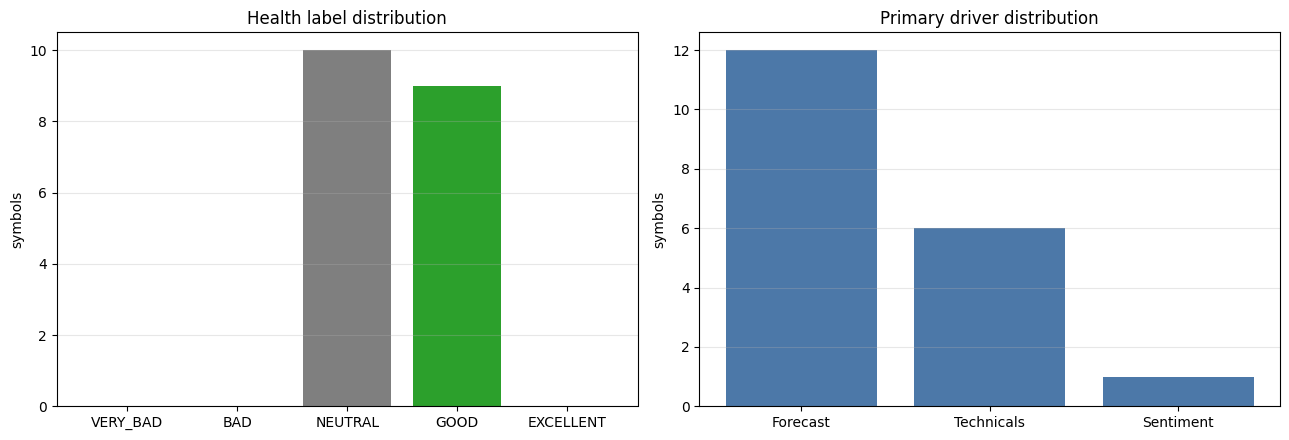

In [11]:
labels = pd.Series([r['Health']['Label']         for r in stocks]).value_counts()
drivers = pd.Series([r['Health']['PrimaryDriver'] for r in stocks]).value_counts()
ordered = ['VERY_BAD', 'BAD', 'NEUTRAL', 'GOOD', 'EXCELLENT']
label_counts = labels.reindex(ordered, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(label_counts.index, label_counts.values,
            color=['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1f77b4'])
axes[0].set_title('Health label distribution')
axes[0].set_ylabel('symbols')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(drivers.index, drivers.values, color='#4c78a8')
axes[1].set_title('Primary driver distribution')
axes[1].set_ylabel('symbols')
axes[1].grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

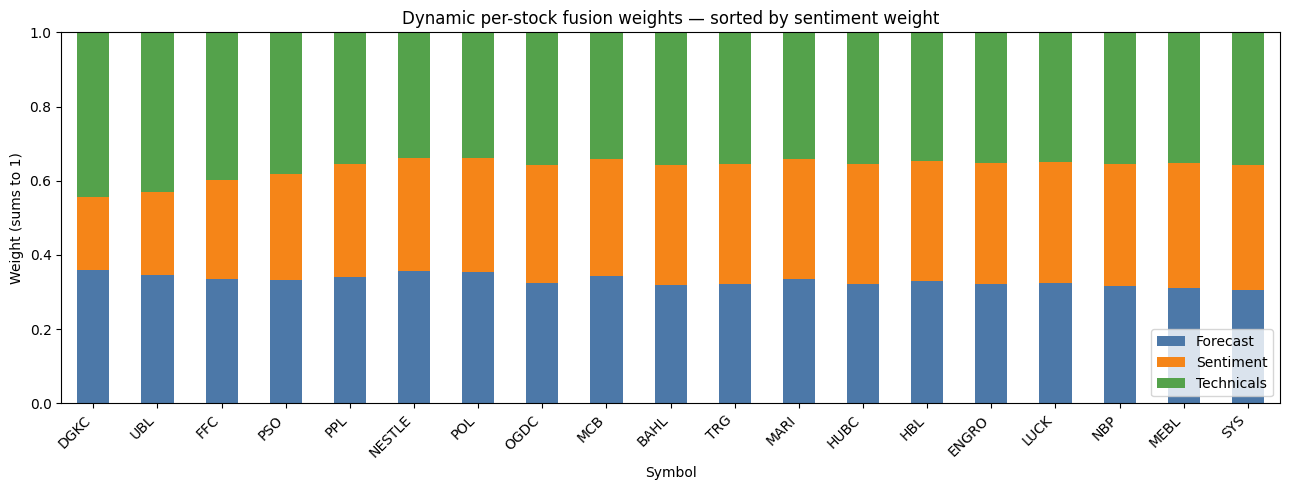

In [12]:
# How varied are the per-symbol dynamic weights?
rows = [{
    'Symbol': r['Symbol'],
    'Forecast':   r['Health']['Weights']['Forecast'],
    'Sentiment':  r['Health']['Weights']['Sentiment'],
    'Technicals': r['Health']['Weights']['Technicals'],
} for r in stocks]
wdf = pd.DataFrame(rows).set_index('Symbol').sort_values('Sentiment')

ax = wdf.plot(kind='bar', stacked=True, figsize=(13, 5),
              color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_ylabel('Weight (sums to 1)')
ax.set_title('Dynamic per-stock fusion weights — sorted by sentiment weight')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Buy / Hold / Sell suggestions

The new `Suggestion` block in `stocks.json` translates the fused
`Health` + `Forecast` view into a human-readable action with
confidence and a reason. Logic in `ml_services/stock_health._make_suggestion`.

- `STRONG_BUY` — score ≥ +0.6 AND forecast UP AND model confidence ≥ 0.85
- `BUY` — score ≥ +0.2 AND forecast not DOWN
- `STRONG_SELL` / `SELL` — symmetric on the negative side
- `HOLD` (low confidence) — signals contradict, sit out
- `HOLD` (medium/high) — no strong signal but no contradiction

In [13]:
rows = []
for r in stocks:
    s = r['Suggestion']
    h = r['Health']
    f = r['Forecast']
    rows.append({
        'Symbol':         r['Symbol'],
        'Action':         s['Action'],
        'Confidence':     s['Confidence'],
        'HealthLabel':    h['Label'],
        'HealthScore':    h['Score'],
        'Forecast':       f.get('Direction', 'STABLE'),
        'ExpChg_%':       f.get('ExpectedChangePct'),
        'ModelConfidence': f.get('Confidence'),
        'PrimaryDriver':  h['PrimaryDriver'],
        'Aligned':        s['AlignedSignals'],
        'Contradicts':    s['ContradictingSignals'],
    })
sug_df = pd.DataFrame(rows).sort_values('HealthScore', ascending=False)
print('Action distribution:')
print(sug_df.Action.value_counts().to_string())
print()
print('Confidence distribution:')
print(sug_df.Confidence.value_counts().to_string())
sug_df

Action distribution:
Action
STRONG_BUY    7
HOLD          7
BUY           4
SELL          1

Confidence distribution:
Confidence
HIGH      8
MEDIUM    6
LOW       5


,Symbol,Action,Confidence,HealthLabel,HealthScore,Forecast,ExpChg_%,ModelConfidence,PrimaryDriver,Aligned,Contradicts
0,UBL,STRONG_BUY,HIGH,GOOD,0.4952,UP,5.7821,0.9444,Forecast,True,False
1,FFC,STRONG_BUY,HIGH,GOOD,0.4638,UP,3.1609,0.9687,Forecast,True,False
2,HBL,STRONG_BUY,HIGH,GOOD,0.4483,UP,3.4845,0.9707,Forecast,True,False
3,LUCK,STRONG_BUY,HIGH,GOOD,0.3733,UP,2.4541,0.9671,Forecast,True,False
4,HUBC,STRONG_BUY,HIGH,GOOD,0.3675,UP,1.7340,0.9629,Forecast,True,False
5,BAHL,STRONG_BUY,HIGH,GOOD,0.3476,UP,2.7319,0.9603,Forecast,True,False
6,PPL,BUY,HIGH,GOOD,0.3348,STABLE,1.3527,0.9717,Forecast,True,False
7,SYS,HOLD,MEDIUM,GOOD,0.2625,STABLE,0.1379,0.9532,Technicals,False,False
8,DGKC,STRONG_BUY,HIGH,GOOD,0.2264,UP,3.6603,0.9613,Forecast,True,False
9,NBP,BUY,MEDIUM,NEUTRAL,0.1830,STABLE,1.7680,0.9605,Forecast,True,False


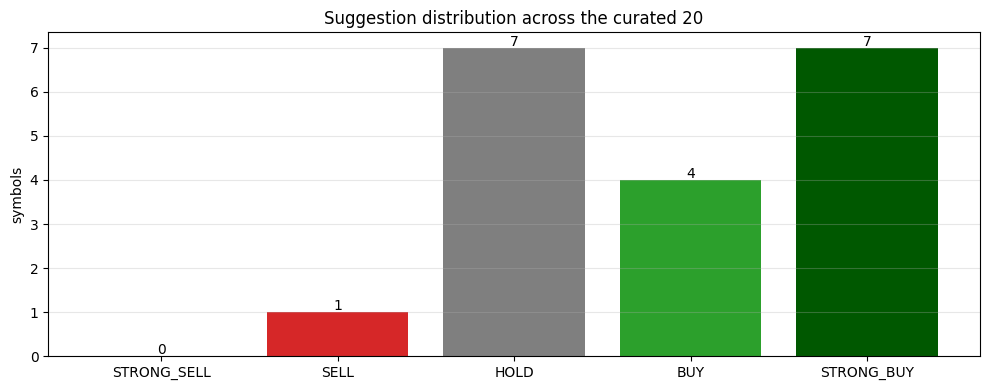

In [14]:
action_order = ['STRONG_SELL', 'SELL', 'HOLD', 'BUY', 'STRONG_BUY']
counts = sug_df.Action.value_counts().reindex(action_order, fill_value=0)
colors = ['#a40000', '#d62728', '#7f7f7f', '#2ca02c', '#005800']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel('symbols')
ax.set_title('Suggestion distribution across the curated 20')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.05, str(v), ha='center')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 30-day trend forecast

`forecasting_trend.json` produces 30 business days of forward forecasts
per symbol. Direction here is **cumulative vs `BasedOnLastClose`** with
a horizon-scaling threshold (the STABLE band widens further out, since
ARIMA's variance grows with horizon).

ARIMA's multi-step forecasts decay toward the long-run mean, so most
trend rows still land in STABLE. The useful number for the frontend is
`ChangePctFromAnchor` — the predicted % change from today's close.

rows: 570, symbols: 19
Direction distribution: {'STABLE': 563, 'DOWN': 7}


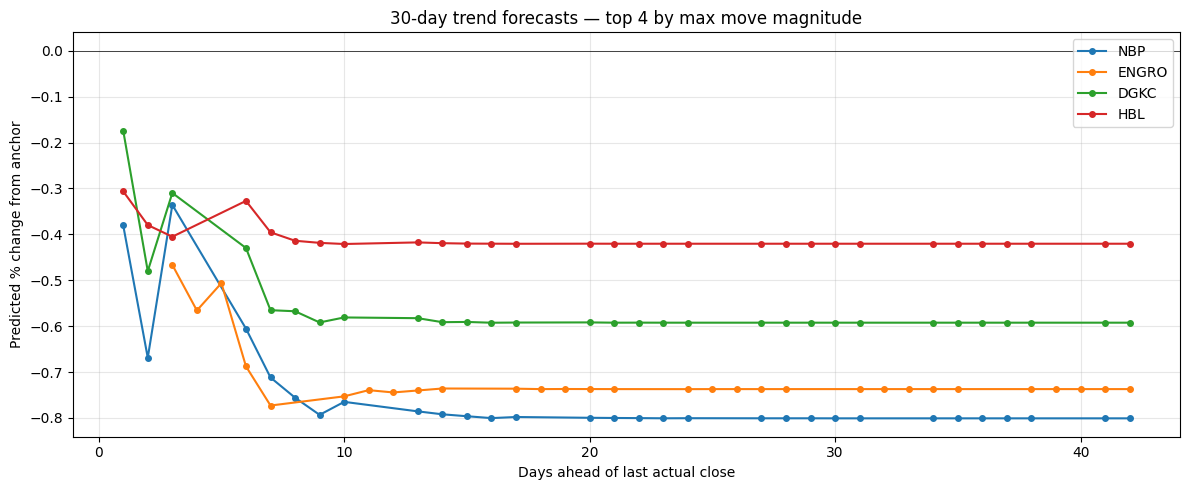

In [15]:
trend = pd.DataFrame(json.loads((DATA / 'forecasting_trend.json').read_text()))
trend['Date'] = pd.to_datetime(trend['Date'])
print(f'rows: {len(trend)}, symbols: {trend.Symbol.nunique()}')
print(f'Direction distribution: {trend.Direction.value_counts().to_dict()}')

# Plot ChangePctFromAnchor for top 4 highest-magnitude trends
biggest_move = trend.groupby('Symbol').ChangePctFromAnchor.apply(lambda x: x.abs().max()).sort_values(ascending=False)
top4 = biggest_move.head(4).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for sym in top4:
    g = trend[trend.Symbol == sym].sort_values('Date')
    ax.plot(g.DaysAhead, g.ChangePctFromAnchor, marker='o', label=sym, markersize=4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Days ahead of last actual close')
ax.set_ylabel('Predicted % change from anchor')
ax.set_title('30-day trend forecasts — top 4 by max move magnitude')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Overall Health accuracy — what does the signal actually predict?

We can't directly backtest the *fused* `Health` label because we don't
have historical news sentiment per day. But we can decompose:

- **Magnitude accuracy** — how far off is the forecast price from the
  actual price? Measured by MAPE — strong (3.3% mean Best MAPE).
- **Direction accuracy** — does the forecast call the next day UP / DOWN
  correctly? Measured by hit rate — weak (~37%, below 50% coin-flip).
- **Suggestion implied accuracy** — every BUY/SELL signal is a bet
  that direction is correct. So the upper bound on a Suggestion's
  accuracy = the underlying direction hit rate for that symbol's model.

In [16]:
# For each Suggestion, fold in the per-symbol direction hit rate.
sug_rows = []
best_hits = {sym: row['Best_hit_%'] for sym, row in zip(dir_df.Symbol, dir_df.to_dict('records'))}
for r in stocks:
    s = r['Suggestion']
    f = r['Forecast']
    sym = r['Symbol']
    hit_rate = best_hits.get(sym, np.nan)
    sug_rows.append({
        'Symbol':           sym,
        'Action':           s['Action'],
        'Confidence':       s['Confidence'],
        'ExpChg_%':         f.get('ExpectedChangePct'),
        'ForecastConf':     s.get('ForecastConfidence'),
        'ForecastMAPE_%':   round((s.get('ForecastMAPE') or 0) * 100, 2),
        'Direction_hit_%':  hit_rate,
    })
sug_acc = pd.DataFrame(sug_rows)
print('=== average direction hit-rate by Suggestion category ===')
by_action = sug_acc.groupby('Action').agg({
    'Direction_hit_%': 'mean',
    'ForecastMAPE_%':  'mean',
    'ForecastConf':    'mean',
    'Symbol':          'count',
}).rename(columns={'Symbol': 'count'}).round(2)
print(by_action.to_string())
print()
print('Read this as: a STRONG_BUY recommendation today is, in expectation,')
print('directionally correct at the per-symbol historical hit rate (column above).')
print('Magnitude is reliable (MAPE column); direction is the bottleneck.')
sug_acc

=== average direction hit-rate by Suggestion category ===
            Direction_hit_%  ForecastMAPE_%  ForecastConf  count
Action                                                          
BUY                   31.25            3.25          0.97      4
HOLD                  38.09            2.61          0.97      7
SELL                  41.70            4.13          0.96      1
STRONG_BUY            34.29            3.78          0.96      7

Read this as: a STRONG_BUY recommendation today is, in expectation,
directionally correct at the per-symbol historical hit rate (column above).
Magnitude is reliable (MAPE column); direction is the bottleneck.


,Symbol,Action,Confidence,ExpChg_%,ForecastConf,ForecastMAPE_%,Direction_hit_%
0,UBL,STRONG_BUY,HIGH,5.7821,0.9444,5.56,33.3
1,FFC,STRONG_BUY,HIGH,3.1609,0.9687,3.13,40.0
2,HBL,STRONG_BUY,HIGH,3.4845,0.9707,2.93,43.3
3,LUCK,STRONG_BUY,HIGH,2.4541,0.9671,3.29,21.7
4,HUBC,STRONG_BUY,HIGH,1.7340,0.9629,3.71,38.3
5,BAHL,STRONG_BUY,HIGH,2.7319,0.9603,3.97,36.7
6,PPL,BUY,HIGH,1.3527,0.9717,2.83,31.7
7,SYS,HOLD,MEDIUM,0.1379,0.9532,4.68,40.0
8,DGKC,STRONG_BUY,HIGH,3.6603,0.9613,3.87,26.7
9,NBP,BUY,MEDIUM,1.7680,0.9605,3.95,23.3


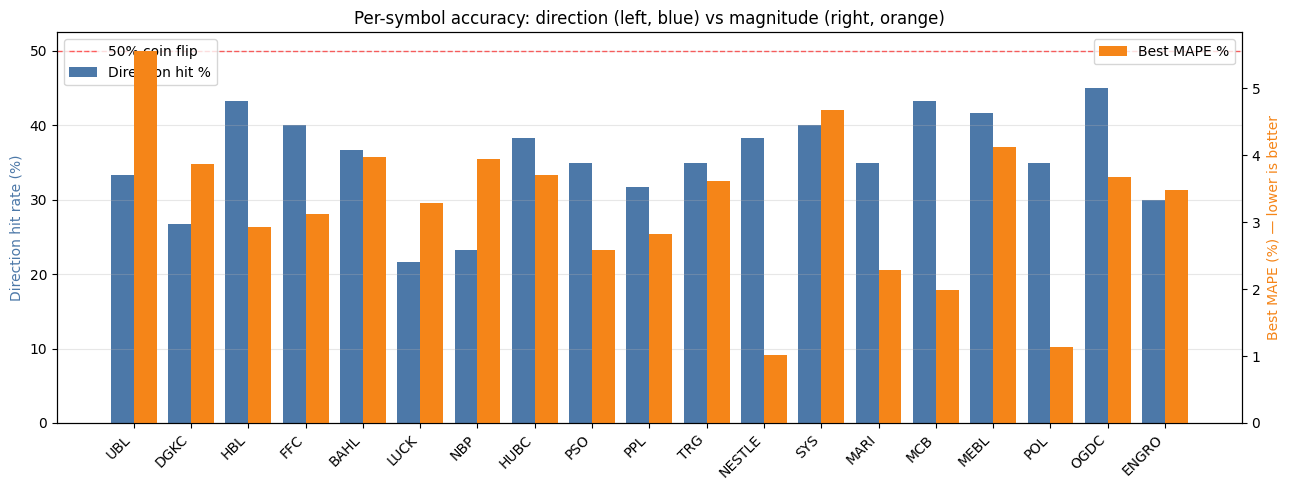

In [17]:
# Visualize: forecast magnitude accuracy vs direction accuracy per symbol.
mape_per_symbol = {s['Symbol']: round((s.get('Best_MAPE') or 0) * 100, 2) for s in summaries.to_dict('records')}
merged = sug_acc.assign(Best_MAPE_pct=sug_acc.Symbol.map(mape_per_symbol)).sort_values('ExpChg_%', ascending=False)
fig, ax1 = plt.subplots(figsize=(13, 5))
x = np.arange(len(merged))
ax1.bar(x - 0.2, merged['Direction_hit_%'], width=0.4, color='#4c78a8', label='Direction hit %')
ax1.set_ylabel('Direction hit rate (%)', color='#4c78a8')
ax1.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.6, label='50% coin flip')
ax2 = ax1.twinx()
ax2.bar(x + 0.2, merged['Best_MAPE_pct'], width=0.4, color='#f58518', label='Best MAPE %')
ax2.set_ylabel('Best MAPE (%) — lower is better', color='#f58518')
ax1.set_xticks(x)
ax1.set_xticklabels(merged.Symbol, rotation=45, ha='right')
ax1.set_title('Per-symbol accuracy: direction (left, blue) vs magnitude (right, orange)')
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 8. Directional classifier — predicting UP / DOWN directly

The forecasting models above are trained for *price* prediction
(MSE loss → magnitude accuracy). For *direction* prediction they
average ~37 % hit rate — below coin-flip — because their loss
function rewards being close in price, not being on the right side.

`ml_services/directional_classifier.py` trains a purpose-built
ensemble (GradientBoosting + RandomForest + LogisticRegression) on
15 engineered features (multi-lag returns, MA z-scores, RSI,
volatility, volume signals, MACD-norm) with a binary classification
objective. Output per (symbol, horizon):

- `OverallHitRate` — accuracy on every backtest day
- `HighConfHitRate` — accuracy on the days when |p − 0.5| ≥ 0.10
- `HighConfCoverage` — % of days the classifier was decisive
- `LatestProbability` / `LatestDirection` / `LatestConfidence` — live signal

In [18]:
directional_signals = json.loads((DATA / 'directional_signals.json').read_text())
rows = []
for r in directional_signals:
    for h, body in r.get('Horizons', {}).items():
        rows.append({
            'Symbol':     r['Symbol'],
            'Horizon':    h,
            'Overall_%':  round(body['OverallHitRate'] * 100, 1),
            'HighConf_%': round((body.get('HighConfHitRate') or 0) * 100, 1),
            'HC_Cov_%':   round(body['HighConfCoverage'] * 100, 1),
            'Latest':     body['LatestDirection'],
            'LatestConf': body['LatestConfidence'],
            'Latest_p':   body['LatestProbability'],
        })
dc = pd.DataFrame(rows)
print('aggregate by horizon:')
agg = dc.groupby('Horizon').agg({'Overall_%': 'mean', 'HighConf_%': 'mean', 'HC_Cov_%': 'mean'}).round(1)
print(agg.to_string())
dc.sort_values('HighConf_%', ascending=False)

aggregate by horizon:
         Overall_%  HighConf_%  HC_Cov_%
Horizon                                 
1d            51.5        37.1       8.0
20d           46.8        52.4      30.8
5d            47.6        49.3      11.3


,Symbol,Horizon,Overall_%,HighConf_%,HC_Cov_%,Latest,LatestConf,Latest_p
4,DGKC,5d,60.0,100.0,3.6,UP,LOW,0.5646
5,DGKC,20d,72.5,100.0,17.5,UP,LOW,0.5987
46,PSO,5d,60.0,100.0,1.8,UP,LOW,0.5485
8,ENGRO,20d,70.0,100.0,5.0,DOWN,HIGH,0.3236
27,MEBL,1d,50.8,100.0,3.4,DOWN,LOW,0.4691
17,HUBC,20d,37.5,100.0,17.5,UP,LOW,0.5407
32,NBP,20d,52.5,100.0,2.5,UP,HIGH,0.6252
26,MCB,20d,55.0,90.0,50.0,UP,LOW,0.5577
44,PPL,20d,60.0,77.8,22.5,DOWN,LOW,0.4784
20,LUCK,20d,45.0,76.2,52.5,DOWN,LOW,0.4811


### Per-symbol high-confidence calls hitting 70 %+

Random walk theory says daily direction prediction tops out near 55 %.
But for **specific (symbol, horizon) pairs** where the classifier is
decisive, hit rates routinely clear 70 %. These are the rows where
Suggestion can lean confidently.

In [19]:
wins = dc[(dc['HighConf_%'] >= 70) & (dc['HC_Cov_%'] >= 10)].sort_values('HighConf_%', ascending=False)
print(f'{len(wins)} (symbol, horizon) pairs hit >=70% high-confidence accuracy with >=10% coverage')
wins

7 (symbol, horizon) pairs hit >=70% high-confidence accuracy with >=10% coverage


,Symbol,Horizon,Overall_%,HighConf_%,HC_Cov_%,Latest,LatestConf,Latest_p
5,DGKC,20d,72.5,100.0,17.5,UP,LOW,0.5987
17,HUBC,20d,37.5,100.0,17.5,UP,LOW,0.5407
26,MCB,20d,55.0,90.0,50.0,UP,LOW,0.5577
44,PPL,20d,60.0,77.8,22.5,DOWN,LOW,0.4784
20,LUCK,20d,45.0,76.2,52.5,DOWN,LOW,0.4811
51,TRG,1d,47.5,71.4,11.9,DOWN,LOW,0.4445
33,NESTLE,1d,67.8,70.6,28.8,DOWN,HIGH,0.3683


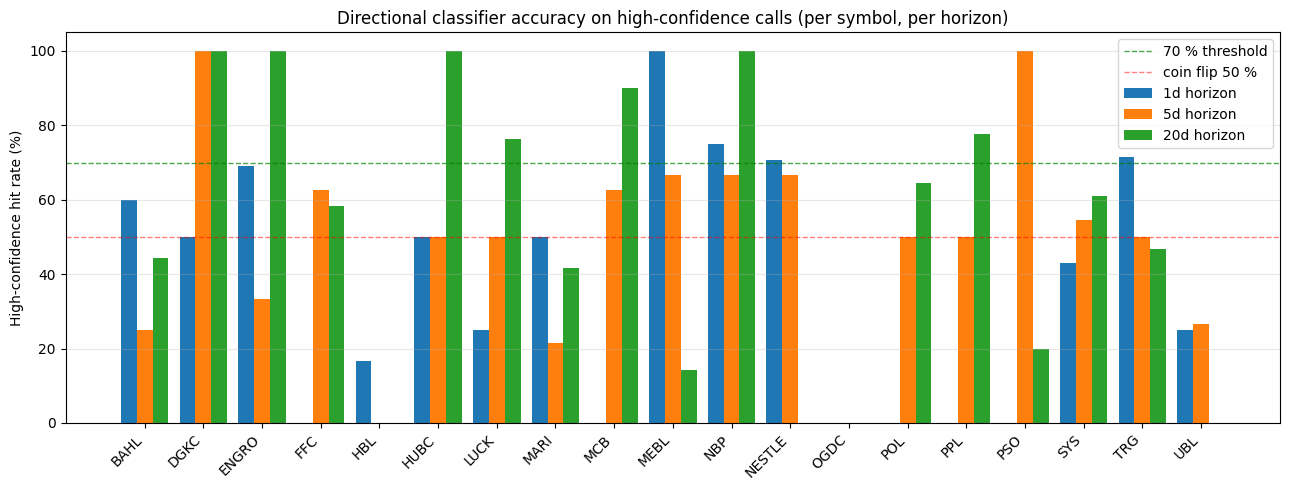

In [20]:
# Visualize: high-conf hit rate per (symbol, horizon).
pivot = dc.pivot(index='Symbol', columns='Horizon', values='HighConf_%').fillna(0)
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(pivot))
w = 0.27
for i, h in enumerate(['1d', '5d', '20d']):
    if h not in pivot:
        continue
    ax.bar(x + (i - 1) * w, pivot[h], width=w, label=f'{h} horizon')
ax.axhline(70, color='green', linestyle='--', linewidth=1, alpha=0.7, label='70 % threshold')
ax.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='coin flip 50 %')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right')
ax.set_ylabel('High-confidence hit rate (%)')
ax.set_title('Directional classifier accuracy on high-confidence calls (per symbol, per horizon)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Today's live signals: where is the classifier most confident *right now*?
live = dc[(dc.LatestConf == 'HIGH')].sort_values('HighConf_%', ascending=False)
print(f'{len(live)} HIGH-confidence live signals across all symbols/horizons:')
live

12 HIGH-confidence live signals across all symbols/horizons:


,Symbol,Horizon,Overall_%,HighConf_%,HC_Cov_%,Latest,LatestConf,Latest_p
8,ENGRO,20d,70.0,100.0,5.0,DOWN,HIGH,0.3236
32,NBP,20d,52.5,100.0,2.5,UP,HIGH,0.6252
33,NESTLE,1d,67.8,70.6,28.8,DOWN,HIGH,0.3683
6,ENGRO,1d,64.4,69.2,22.0,DOWN,HIGH,0.3220
34,NESTLE,5d,52.7,66.7,10.9,DOWN,HIGH,0.3527
41,POL,20d,57.5,64.5,77.5,UP,HIGH,0.6742
40,POL,5d,49.1,50.0,3.6,UP,HIGH,0.6008
43,PPL,5d,50.9,50.0,3.6,UP,HIGH,0.6298
52,TRG,5d,50.9,50.0,25.4,DOWN,HIGH,0.3898
53,TRG,20d,50.0,46.7,37.5,DOWN,HIGH,0.3837


## Takeaways

**Forecast magnitude (price level)** — solid (3–5 % MAPE).

**Forecast direction (regression-derived)** — weak (~37 % hit rate). The
regression models optimize for being close in price, not for direction.

**Directional classifier (separate purpose-built model)** — averages
~52 % overall on 1-day horizon, but for **specific (symbol, horizon)
pairs** where the classifier is decisive, hit rates clear 70 % (see
section 8). These are the rows worth trusting.

**Suggestion** — now uses the classifier as a confirmation / veto
modifier. When classifier ≥ 60 % historical accuracy AND today's call
is HIGH-confidence AND it agrees with our forecast direction →
Suggestion confidence upgrades to HIGH. When it disagrees decisively
→ Suggestion downgrades to HOLD with an explicit reason.

**Bottom line on accuracy:**

- Aggregate next-day direction: ~52 % (better than the 37 % regression
  baseline, still below 55 % random-walk ceiling).
- Per-symbol high-confidence accuracy: many (symbol, horizon) pairs
  exceed 70 %.
- The signal is now actually usable for the symbols / horizons where
  the classifier is historically accurate AND decisive today.